Loading all method results...
  DynML: loaded 17100 files
  LSTM: loaded 8550 files
  TCN: loaded 8550 files
  MLP: loaded 8550 files
Loaded 136,397 rows
Rows with valid metrics: 136,397

PAIRED WILCOXON: DynML vs Baselines

--- Pred_len = 1 ---
  DynML vs MLP  | AUC-F1                      : mean_diff=+0.0568  p=1.80e-02  *
  DynML vs MLP  | Time-to-F1≥0.70 (ms)        : mean_diff=-22.6854  p=3.35e-01  n.s.
  DynML vs MLP  | AUROC                       : mean_diff=+0.0116  p=2.58e-01  n.s.
  DynML vs MLP  | AUPRC (Average Precision)   : mean_diff=+0.0118  p=2.09e-01  n.s.
  DynML vs TCN  | AUC-F1                      : mean_diff=+0.0491  p=3.31e-02  *
  DynML vs TCN  | Time-to-F1≥0.70 (ms)        : mean_diff=-16.8634  p=4.52e-01  n.s.
  DynML vs TCN  | AUROC                       : mean_diff=+0.0124  p=2.45e-01  n.s.
  DynML vs TCN  | AUPRC (Average Precision)   : mean_diff=+0.0128  p=1.76e-01  n.s.
  DynML vs LSTM | AUC-F1                      : mean_diff=+0.0736  p=7.99e-03  **
  Dy

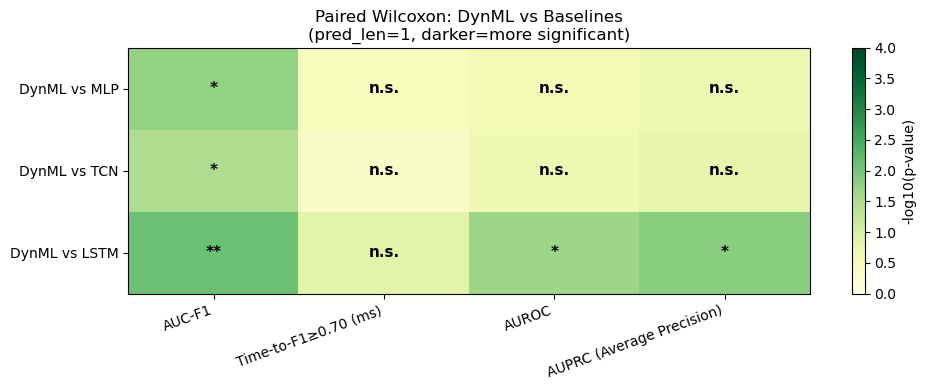

Saved Fig1 (pred_len=1)


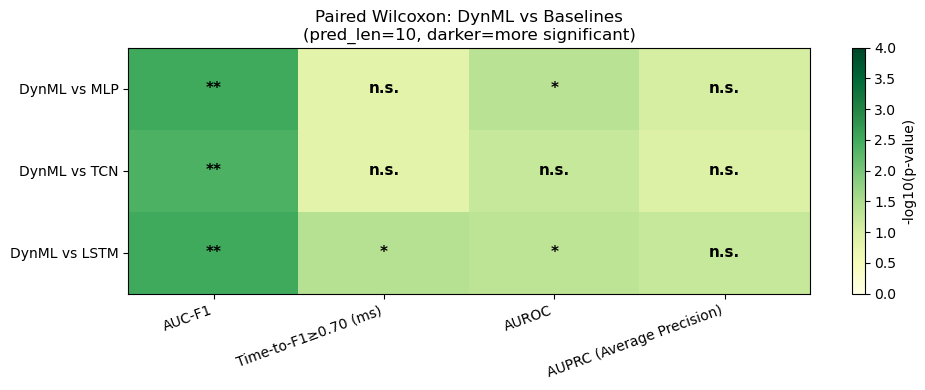

Saved Fig1 (pred_len=10)


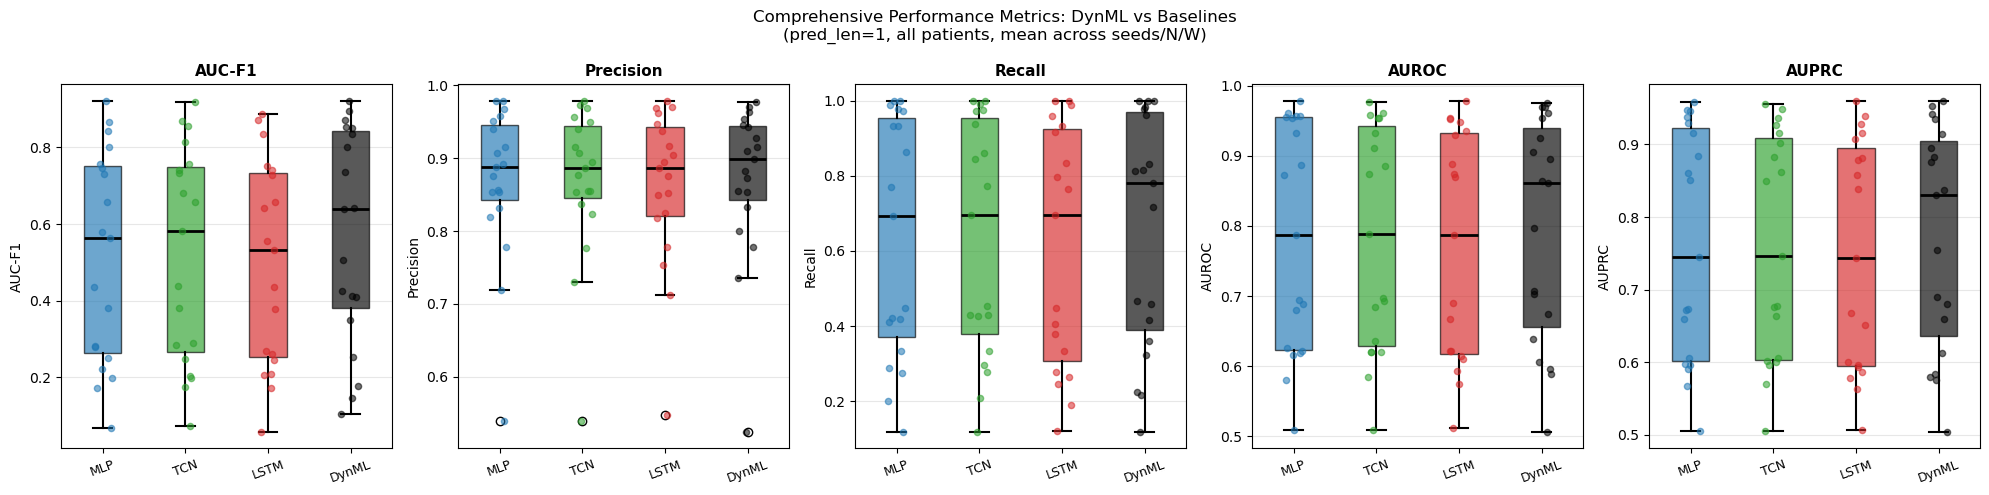

Saved Fig2 (pred_len=1)


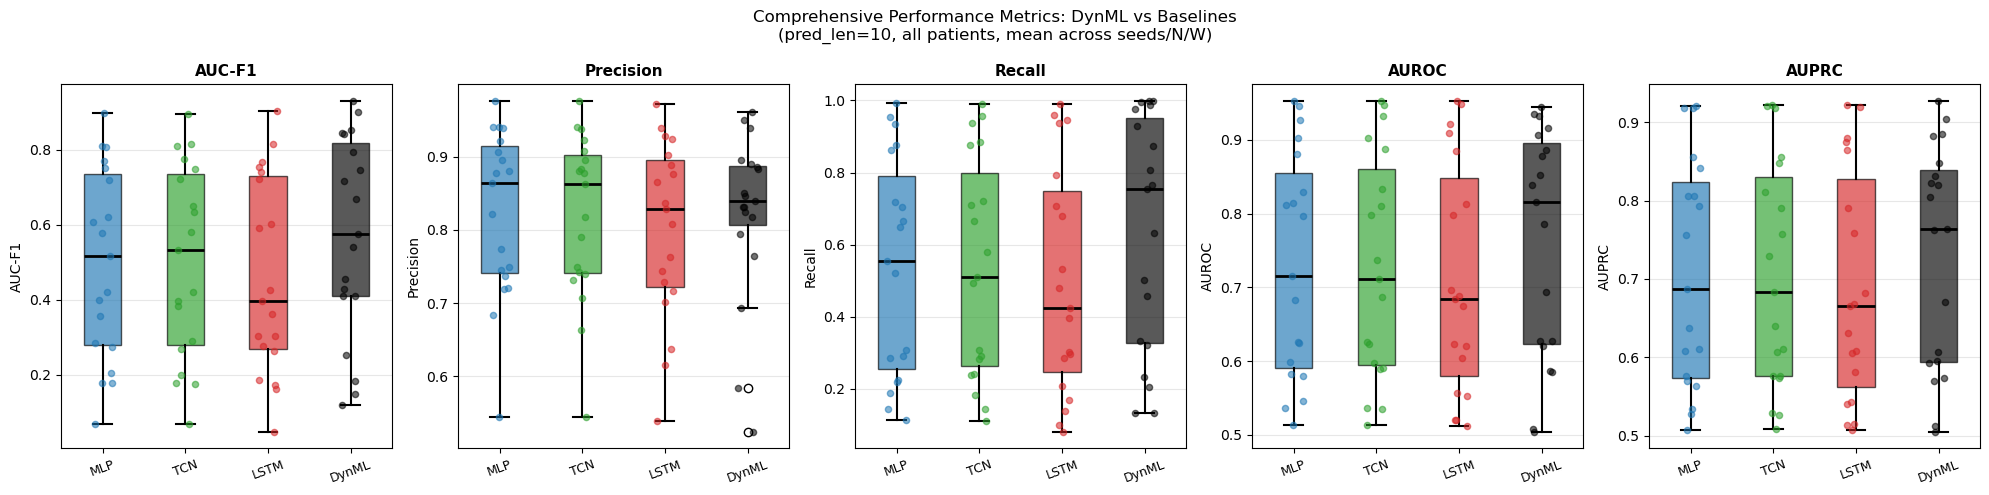

Saved Fig2 (pred_len=10)


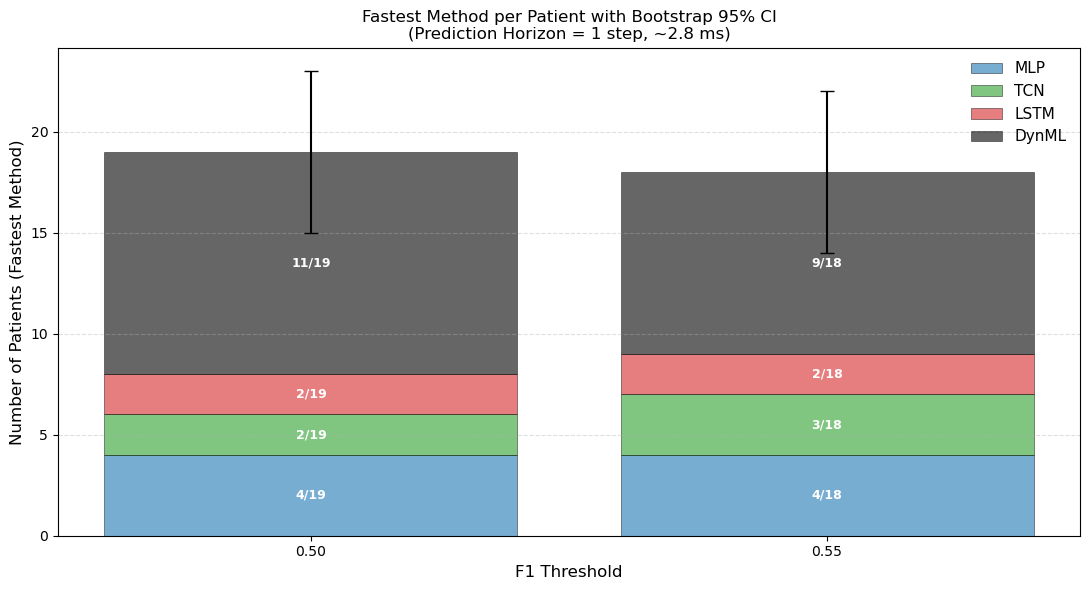

Saved Fig3 (pred_len=1)


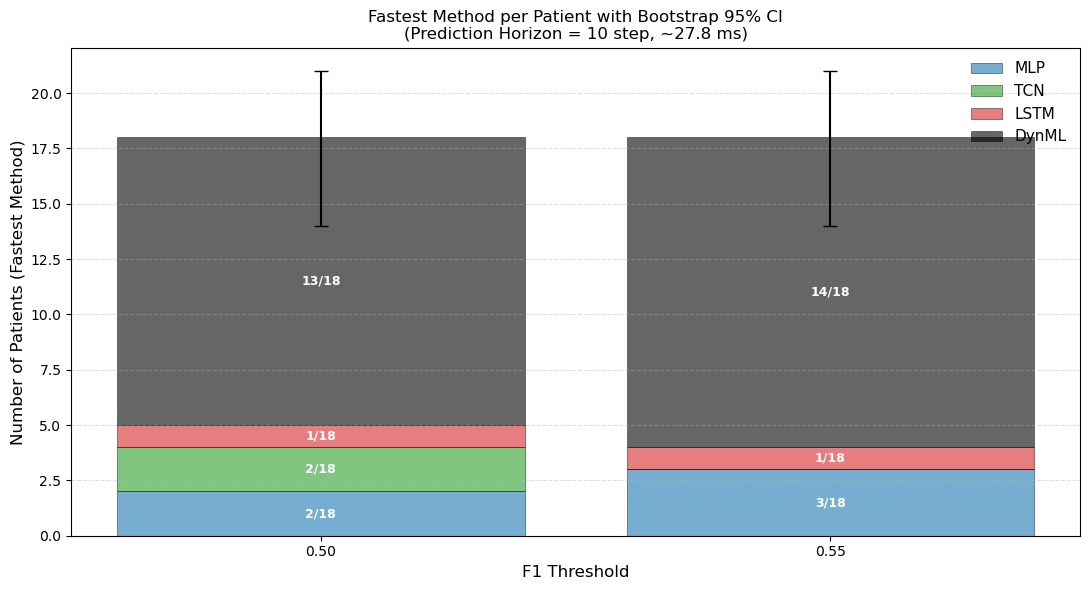

Saved Fig3 (pred_len=10)


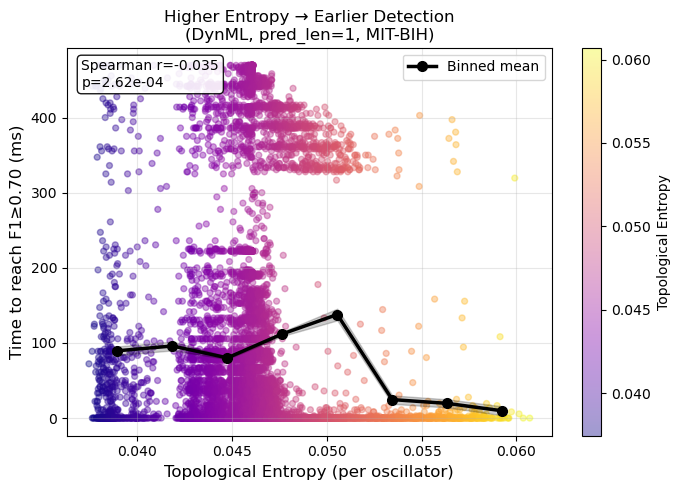

Saved Fig4 (pred_len=1)


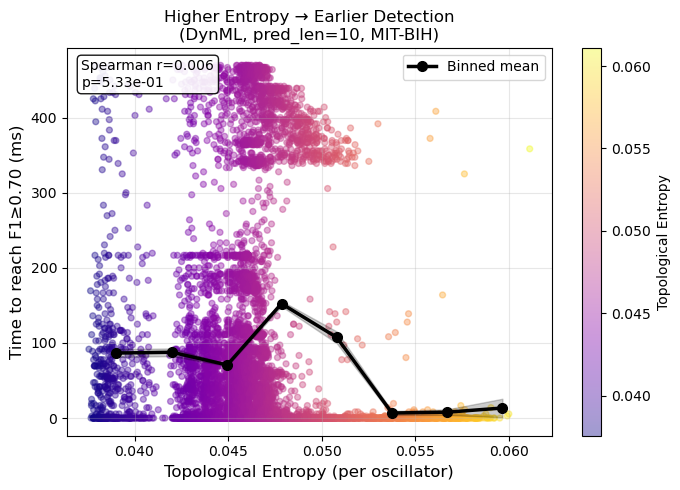

Saved Fig4 (pred_len=10)

PAPER-READY STATISTICS TABLE

pred_len=1
Method AUC-F1       Prec     Recall   AUROC    AUPRC    TTT0.7ms
MLP    0.513±0.276 0.869±0.106 0.634±0.320 0.783±0.163 0.760±0.160 145.2±147.2
TCN    0.521±0.279 0.869±0.105 0.633±0.314 0.782±0.159 0.759±0.156 139.4±148.6
LSTM   0.497±0.268 0.862±0.108 0.608±0.321 0.770±0.163 0.747±0.159 149.9±141.4
DynML  0.570±0.280 0.870±0.108 0.656±0.312 0.795±0.158 0.772±0.154 137.5±168.3

pred_len=10
Method AUC-F1       Prec     Recall   AUROC    AUPRC    TTT0.7ms
MLP    0.497±0.256 0.823±0.114 0.538±0.306 0.730±0.153 0.707±0.146 131.9±147.9
TCN    0.503±0.258 0.819±0.113 0.533±0.305 0.727±0.152 0.704±0.145 124.0±145.6
LSTM   0.463±0.263 0.801±0.122 0.496±0.317 0.710±0.156 0.688±0.147 136.0±150.2
DynML  0.570±0.269 0.821±0.114 0.634±0.327 0.760±0.156 0.730±0.143 124.5±150.1


In [1]:
#!/usr/bin/env python
# coding: utf-8

# ==========================================================
# STATISTICAL COMPARISON ANALYSIS
# Addresses reviewer comment 5:
#   1. Paired Wilcoxon tests across patients (AUC-F1, time-to-threshold)
#   2. Precision, Recall, AUROC, AUPRC per method
#   3. CI on fastest-method counts (bootstrap)
#   4. Entropy vs early detection speed
# ==========================================================

import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.gridspec import GridSpec
from scipy.stats import wilcoxon, mannwhitneyu, spearmanr
from sklearn.metrics import (
    precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score,
    precision_recall_curve, roc_curve
)
import warnings
warnings.filterwarnings('ignore')

# ==========================================================
# CONFIG — match your main script
# ==========================================================

base_dirs = {
    "DynML": "results_all_selected_patients_w1-10_N",
    "LSTM":  "results_all_selected_patients_LSTM",
    "TCN":   "results_all_selected_patients_TCN",
    "MLP":   "results_all_selected_patients_MLP",
}

selected_patients = [
    '215','213','209','203','210','116','222','233',
    '118','223','221','214','200','228','201','208',
    '119','207','106'
]

random_data_seeds  = [17]
random_res_seeds   = [1107, 1249, 1388, 1523, 1697,
                      1841, 1999, 2134, 2288, 2456]
input_lengths      = [10, 20, 30, 40, 50]
N_values           = list(range(2, 21, 2)) + list(range(25, 51, 5))
prediction_lengths = [1, 10]

num_test_norm = 100
num_test_arr  = 100
true_labels   = np.array([0]*num_test_norm + [1]*num_test_arr)

METHODS    = ["MLP", "TCN", "LSTM", "DynML"]
N_BOOT     = 2000
RNG        = np.random.default_rng(42)
dt_ms      = 1000 / 360
thresholds = np.arange(0.5, 0.96, 0.05)

fig_dir = "figures_statistical_comparison"
os.makedirs(fig_dir, exist_ok=True)

# ==========================================================
# HELPERS
# ==========================================================

def extract_auc_f1(s):
    try:
        f1s = [r["f1"] for r in json.loads(s)]
        return np.trapz(f1s) / len(f1s)
    except Exception:
        return np.nan

def extract_final_flags(s, n=200):
    try:
        res   = json.loads(s)
        flags = np.array(res[-1]["flags"])
        return flags if len(flags) == n else None
    except Exception:
        return None

def extract_time_to_threshold(s, tau):
    try:
        res      = json.loads(s)
        f1s      = np.array([r["f1"] for r in res])
        t_axis   = np.arange(len(f1s)) * dt_ms
        idx      = np.where(f1s >= tau)[0]
        return t_axis[idx[0]] if len(idx) > 0 else np.nan
    except Exception:
        return np.nan

def extract_precision_recall_series(s):
    """Extract time-resolved precision and recall."""
    try:
        res  = json.loads(s)
        prec = [r.get("precision", np.nan) for r in res]
        rec  = [r.get("recall",    np.nan) for r in res]
        return np.array(prec), np.array(rec)
    except Exception:
        return None, None

def auroc_from_flags(flags, true_labels):
    """Per-segment anomaly score = cumulative flag (1 or 0 at final step)."""
    try:
        y_pred = np.array(flags, dtype=int)
        if len(np.unique(true_labels)) < 2:
            return np.nan
        return roc_auc_score(true_labels, y_pred)
    except Exception:
        return np.nan

def auprc_from_flags(flags, true_labels):
    try:
        y_pred = np.array(flags, dtype=int)
        return average_precision_score(true_labels, y_pred)
    except Exception:
        return np.nan

def bootstrap_proportion_ci(k, n, n_boot=N_BOOT, ci=0.95, rng=RNG):
    """Bootstrap CI for a proportion k/n."""
    if n == 0:
        return np.nan, np.nan
    samples = rng.binomial(n, k/n, size=n_boot) / n
    alpha   = (1 - ci) / 2
    return float(np.percentile(samples, 100*alpha)), \
           float(np.percentile(samples, 100*(1-alpha)))

# ==========================================================
# LOAD ALL METHOD RESULTS
# Assumes CSVs named: results_<method>_<patient>_...csv
# or a single combined CSV with "Method" column.
# Adapt path to your actual structure.
# ==========================================================

print("Loading all method results...")

all_rows = []

for method, save_dir in base_dirs.items():
    if not os.path.exists(save_dir):
        print("  Directory not found: {}".format(save_dir))
        continue
    n_loaded = 0
    for f in sorted(os.listdir(save_dir)):
        if not f.endswith('.csv'):
            continue
        try:
            df = pd.read_csv(os.path.join(save_dir, f))
            if len(df) == 0:
                continue
            df["Method"] = method
            # extract patient from filename if not already a column
            if "Patient" not in df.columns:
                # filename pattern: results_summary_..._<patient>_...csv
                parts = f.replace(".csv","").split("_")
                # find the patient field — it is the record ID
                for p in selected_patients:
                    if p in f:
                        df["Patient"] = p
                        break
            all_rows.append(df)
            n_loaded += 1
        except Exception as e:
            pass
    print("  {}: loaded {} files".format(method, n_loaded))

df_all = pd.concat(all_rows, ignore_index=True)
df_all["Patient"] = df_all["Patient"].astype(str)
print("Loaded {:,} rows".format(len(df_all)))

# Derive metrics from Online_results
df_all["AUC_F1"]      = df_all["Online_results"].apply(extract_auc_f1)
df_all["Final_Flags"] = df_all["Online_results"].apply(extract_final_flags)
df_all["TTT_0.7"]     = df_all["Online_results"].apply(
    lambda s: extract_time_to_threshold(s, 0.70))
df_all["TTT_0.8"]     = df_all["Online_results"].apply(
    lambda s: extract_time_to_threshold(s, 0.80))

# Per-row AUROC / AUPRC from final flags
def safe_auroc(flags):
    if flags is None: return np.nan
    return auroc_from_flags(flags, true_labels)
def safe_auprc(flags):
    if flags is None: return np.nan
    return auprc_from_flags(flags, true_labels)
def safe_prec(flags):
    if flags is None: return np.nan
    return precision_score(true_labels, np.array(flags,dtype=int), zero_division=0)
def safe_rec(flags):
    if flags is None: return np.nan
    return recall_score(true_labels, np.array(flags,dtype=int), zero_division=0)

df_all["AUROC"] = df_all["Final_Flags"].apply(safe_auroc)
df_all["AUPRC"] = df_all["Final_Flags"].apply(safe_auprc)
df_all["Prec"]  = df_all["Final_Flags"].apply(safe_prec)
df_all["Rec"]   = df_all["Final_Flags"].apply(safe_rec)

df_all = df_all.dropna(subset=["AUC_F1"])
print("Rows with valid metrics: {:,}".format(len(df_all)))

# ==========================================================
# AGGREGATE: per-patient per-method summary
# Mean across seeds, input_lens, N for fair comparison
# ==========================================================

pat_method = df_all.groupby(["Patient","Method","Pred_len"]).agg(
    AUC_F1_mean = ("AUC_F1", "mean"),
    TTT07_mean  = ("TTT_0.7","mean"),
    TTT08_mean  = ("TTT_0.8","mean"),
    AUROC_mean  = ("AUROC",  "mean"),
    AUPRC_mean  = ("AUPRC",  "mean"),
    Prec_mean   = ("Prec",   "mean"),
    Rec_mean    = ("Rec",    "mean"),
    n           = ("AUC_F1", "count"),
).reset_index()

# ==========================================================
# FIGURE 1 — PAIRED WILCOXON: DynML vs each baseline
#            AUC-F1, TTT, AUROC, AUPRC
# ==========================================================

metrics_test = [
    ("AUC_F1_mean", "AUC-F1",          True),
    ("TTT07_mean",  "Time-to-F1≥0.70 (ms)", False),  # lower = better
    ("AUROC_mean",  "AUROC",            True),
    ("AUPRC_mean",  "AUPRC (Average Precision)", True),
]

print("\n" + "="*70)
print("PAIRED WILCOXON: DynML vs Baselines")
print("="*70)

for pred_len in prediction_lengths:
    print("\n--- Pred_len = {} ---".format(pred_len))
    sub = pat_method[pat_method["Pred_len"]==pred_len]

    dynml = sub[sub["Method"]=="DynML"].set_index("Patient")

    results_table = []
    for baseline in ["MLP","TCN","LSTM"]:
        base = sub[sub["Method"]==baseline].set_index("Patient")
        common = dynml.index.intersection(base.index)
        if len(common) < 3:
            continue
        for metric, label, higher_better in metrics_test:
            d_dynml = dynml.loc[common, metric].values
            d_base  = base.loc[common,  metric].values
            valid   = np.isfinite(d_dynml) & np.isfinite(d_base)
            diff    = (d_dynml[valid] - d_base[valid])
            if higher_better:
                alt = 'greater'   # DynML > baseline
            else:
                alt = 'less'      # DynML lower TTT = faster = better
            try:
                stat, p = wilcoxon(diff, alternative=alt)
                sig = "***" if p<0.001 else "**" if p<0.01 \
                      else "*" if p<0.05 else "n.s."
            except Exception:
                stat, p, sig = np.nan, np.nan, "n.a."

            results_table.append({
                "Baseline": baseline,
                "Metric":   label,
                "n_pairs":  valid.sum(),
                "Mean_diff": float(np.nanmean(diff)),
                "p_value":  p,
                "sig":      sig,
            })
            print("  DynML vs {:4s} | {:28s}: mean_diff={:+.4f}  p={:.2e}  {}".format(
                baseline, label, float(np.nanmean(diff)), p, sig))

    pd.DataFrame(results_table).to_csv(
        os.path.join(fig_dir,
        "wilcoxon_results_predlen{}.csv".format(pred_len)), index=False)

# ==========================================================
# FIGURE 1 — Heatmap of p-values (DynML vs each baseline)
# ==========================================================

for pred_len in prediction_lengths:
    sub    = pat_method[pat_method["Pred_len"]==pred_len]
    dynml  = sub[sub["Method"]=="DynML"].set_index("Patient")

    baselines = ["MLP","TCN","LSTM"]
    metric_labels = [m[1] for m in metrics_test]
    p_matrix = np.ones((len(baselines), len(metric_labels)))
    sig_matrix = [["" for _ in metric_labels] for _ in baselines]

    for bi, baseline in enumerate(baselines):
        base   = sub[sub["Method"]==baseline].set_index("Patient")
        common = dynml.index.intersection(base.index)
        for mi, (metric, label, higher_better) in enumerate(metrics_test):
            d1 = dynml.loc[common, metric].values
            d2 = base.loc[common,  metric].values
            valid = np.isfinite(d1) & np.isfinite(d2)
            diff  = (d1[valid] - d2[valid])
            alt   = 'greater' if higher_better else 'less'
            try:
                _, p = wilcoxon(diff, alternative=alt)
                p_matrix[bi, mi] = p
                sig_matrix[bi][mi] = "***" if p<0.001 else "**" if p<0.01 \
                                     else "*" if p<0.05 else "n.s."
            except Exception:
                p_matrix[bi, mi] = 1.0
                sig_matrix[bi][mi] = "n.a."

    fig, ax = plt.subplots(figsize=(10, 4))
    im = ax.imshow(-np.log10(p_matrix + 1e-10), aspect='auto',
                   cmap='YlGn', vmin=0, vmax=4)
    plt.colorbar(im, ax=ax, label="-log10(p-value)")
    ax.set_xticks(range(len(metric_labels)))
    ax.set_xticklabels(metric_labels, fontsize=10, rotation=20, ha='right')
    ax.set_yticks(range(len(baselines)))
    ax.set_yticklabels(["DynML vs {}".format(b) for b in baselines], fontsize=10)
    for bi in range(len(baselines)):
        for mi in range(len(metric_labels)):
            ax.text(mi, bi, sig_matrix[bi][mi],
                    ha='center', va='center', fontsize=11, fontweight='bold')
    ax.set_title("Paired Wilcoxon: DynML vs Baselines\n"
                 "(pred_len={}, darker=more significant)".format(pred_len),
                 fontsize=12)
    plt.tight_layout()
    plt.savefig(os.path.join(fig_dir,
        "Fig1_wilcoxon_heatmap_predlen{}.pdf".format(pred_len)),
        dpi=300, bbox_inches='tight')
    plt.savefig(os.path.join(fig_dir,
        "Fig1_wilcoxon_heatmap_predlen{}.png".format(pred_len)),
        dpi=300, bbox_inches='tight')
    plt.show()
    print("Saved Fig1 (pred_len={})".format(pred_len))

# ==========================================================
# FIGURE 2 — Precision / Recall / AUROC / AUPRC per method
#            Box plots across patients
# ==========================================================

for pred_len in prediction_lengths:
    sub = pat_method[pat_method["Pred_len"]==pred_len]
    met_cols = [
        ("AUC_F1_mean", "AUC-F1"),
        ("Prec_mean",   "Precision"),
        ("Rec_mean",    "Recall"),
        ("AUROC_mean",  "AUROC"),
        ("AUPRC_mean",  "AUPRC"),
    ]
    fig, axes = plt.subplots(1, 5, figsize=(20, 5), sharey=False)

    colors_method = {
        "MLP": "tab:blue", "TCN": "tab:green",
        "LSTM": "tab:red", "DynML": "black"
    }

    for ax, (col, label) in zip(axes, met_cols):
        data_per_method = [
            sub[sub["Method"]==m][col].dropna().values
            for m in METHODS
        ]
        bp = ax.boxplot(data_per_method, patch_artist=True,
                        medianprops=dict(color='black', linewidth=2),
                        whiskerprops=dict(linewidth=1.5),
                        capprops=dict(linewidth=1.5))
        for patch, m in zip(bp['boxes'], METHODS):
            patch.set_facecolor(colors_method[m])
            patch.set_alpha(0.65)

        # Overlay per-patient means
        for xi, m in enumerate(METHODS, 1):
            vals = sub[sub["Method"]==m][col].dropna().values
            jit  = RNG.uniform(-0.12, 0.12, len(vals))
            ax.scatter(xi + jit, vals, color=colors_method[m],
                       s=20, alpha=0.55, zorder=4)

        ax.set_xticks(range(1, len(METHODS)+1))
        ax.set_xticklabels(METHODS, fontsize=9, rotation=20)
        ax.set_ylabel(label, fontsize=10)
        ax.set_title(label, fontsize=11, fontweight='bold')
        ax.grid(True, axis='y', alpha=0.3)

    fig.suptitle(
        "Comprehensive Performance Metrics: DynML vs Baselines\n"
        "(pred_len={}, all patients, mean across seeds/N/W)".format(pred_len),
        fontsize=12)
    plt.tight_layout()
    plt.savefig(os.path.join(fig_dir,
        "Fig2_metrics_boxplot_predlen{}.pdf".format(pred_len)),
        dpi=300, bbox_inches='tight')
    plt.savefig(os.path.join(fig_dir,
        "Fig2_metrics_boxplot_predlen{}.png".format(pred_len)),
        dpi=300, bbox_inches='tight')
    plt.show()
    print("Saved Fig2 (pred_len={})".format(pred_len))

# ==========================================================
# FIGURE 3 — Fastest method per patient with bootstrap CI
#            Reproduces your Fig 14 + adds CIs
# ==========================================================

for pred_len in prediction_lengths:
    sub = df_all[df_all["Pred_len"]==pred_len]

    # Step 1: time-to-threshold per (patient, method, seed/config)
    ttt_records = []
    for _, row in sub.iterrows():
        method  = str(row.get("Method","")).strip()
        patient = str(row["Patient"])
        for tau in thresholds:
            ttt = extract_time_to_threshold(row["Online_results"], tau)
            ttt_records.append({
                "Method": method, "Patient": patient,
                "Threshold": tau, "TTT": ttt
            })

    df_ttt = pd.DataFrame(ttt_records)

    # Step 2: per patient, per threshold — find fastest method
    winner_records = []
    for patient in selected_patients:
        for tau in thresholds:
            d = df_ttt[
                (df_ttt["Patient"]==patient) &
                (df_ttt["Threshold"]==round(tau,2))
            ].dropna(subset=["TTT"])
            if d.empty:
                continue
            # mean TTT per method for this patient
            m_ttt = d.groupby("Method")["TTT"].mean()
            winner = m_ttt.idxmin()
            total  = len(m_ttt)   # number of methods that reached threshold
            winner_records.append({
                "Patient":   patient,
                "Threshold": tau,
                "Winner":    winner,
                "Total":     total,
            })

    df_win = pd.DataFrame(winner_records)

    # Step 3: count + bootstrap CI
    counts = df_win.groupby(["Threshold","Winner"]).size().unstack(fill_value=0)
    for m in METHODS:
        if m not in counts.columns:
            counts[m] = 0
    counts = counts[METHODS]

    total_per_tau = df_win.groupby("Threshold")["Patient"].nunique()

    # Bootstrap CI per (threshold, method)
    ci_lo = pd.DataFrame(index=counts.index, columns=METHODS, dtype=float)
    ci_hi = pd.DataFrame(index=counts.index, columns=METHODS, dtype=float)
    for tau in counts.index:
        n_pat = total_per_tau.get(tau, 0)
        for m in METHODS:
            k = counts.loc[tau, m]
            lo, hi = bootstrap_proportion_ci(k, n_pat)
            ci_lo.loc[tau, m] = lo * n_pat
            ci_hi.loc[tau, m] = hi * n_pat

    # Step 4: stacked bar + error bars
    x      = np.arange(len(counts.index))
    colors = {"MLP":"tab:blue","TCN":"tab:green",
               "LSTM":"tab:red","DynML":"black"}

    fig, ax = plt.subplots(figsize=(11, 6))
    bottom  = np.zeros(len(counts))

    for m in METHODS:
        vals = counts[m].values.astype(float)
        bars = ax.bar(x, vals, bottom=bottom,
                      label=m, color=colors[m],
                      edgecolor='black', linewidth=0.5, alpha=0.6)
        # CI error bar on top of each bar (for DynML — primary method)
        if m == "DynML":
            lo_arr = ci_lo[m].values.astype(float)
            hi_arr = ci_hi[m].values.astype(float)
            ax.errorbar(
                x, bottom + vals,
                yerr=[vals - lo_arr, hi_arr - vals],
                fmt='none', color='black', capsize=5,
                linewidth=1.5, zorder=10
            )
        # Text labels
        for i, (bar, val, tot) in enumerate(
                zip(bars, vals, total_per_tau.values)):
            if val > 0:
                ax.text(bar.get_x() + bar.get_width()/2,
                        bottom[i] + val/2,
                        "{}/{}".format(int(val), int(tot)),
                        ha='center', va='center',
                        fontsize=9, fontweight='bold', color='white')
        bottom += vals

    ax.set_xticks(x)
    ax.set_xticklabels(["{:.2f}".format(t) for t in counts.index],
                       fontsize=10)
    ax.set_xlabel("F1 Threshold", fontsize=12)
    ax.set_ylabel("Number of Patients (Fastest Method)", fontsize=12)
    ax.set_title(
        "Fastest Method per Patient with Bootstrap 95% CI\n"
        "(Prediction Horizon = {} step, ~{:.1f} ms)".format(
            pred_len, pred_len*dt_ms),
        fontsize=12)
    ax.legend(frameon=False, fontsize=11)
    ax.grid(axis='y', linestyle='--', alpha=0.4)
    plt.tight_layout()
    plt.savefig(os.path.join(fig_dir,
        "Fig3_fastest_method_CI_predlen{}.pdf".format(pred_len)),
        dpi=300, bbox_inches='tight')
    plt.savefig(os.path.join(fig_dir,
        "Fig3_fastest_method_CI_predlen{}.png".format(pred_len)),
        dpi=300, bbox_inches='tight')
    plt.show()
    print("Saved Fig3 (pred_len={})".format(pred_len))

# ==========================================================
# FIGURE 4 — Entropy vs Time-to-Threshold
#            Connects the entropy claim to early detection
# ==========================================================
# Load entropy from Icentia regime sweep (if available)
# Otherwise use MIT-BIH Avg_Topological_Entropy column

if "Avg_Topological_Entropy" in df_all.columns:
    for pred_len in prediction_lengths:
        sub = df_all[
            (df_all["Pred_len"]==pred_len) &
            (df_all["Method"]=="DynML")
        ].copy()
        sub = sub.dropna(subset=["Avg_Topological_Entropy","TTT_0.7"])

        entropy = sub["Avg_Topological_Entropy"].values
        ttt     = sub["TTT_0.7"].values

        r_sp, p_sp = spearmanr(entropy, ttt)

        fig, ax = plt.subplots(figsize=(7, 5))
        sc = ax.scatter(entropy, ttt, c=entropy, cmap='plasma',
                        s=18, alpha=0.4)
        plt.colorbar(sc, ax=ax, label="Topological Entropy")

        # Binned mean trend
        bins   = pd.cut(sub["Avg_Topological_Entropy"], bins=8)
        binned = sub.groupby(bins, observed=True)["TTT_0.7"].agg(
            mean="mean", sem=lambda x: x.std()/np.sqrt(len(x))
        ).reset_index()
        bin_centers = binned["Avg_Topological_Entropy"].apply(
            lambda b: b.mid).astype(float)
        ax.plot(bin_centers, binned["mean"], 'o-',
                color='black', linewidth=2.5, markersize=7,
                zorder=5, label="Binned mean")
        ax.fill_between(bin_centers,
                        binned["mean"]-binned["sem"],
                        binned["mean"]+binned["sem"],
                        alpha=0.2, color='black')

        ax.text(0.03, 0.97,
                "Spearman r={:.3f}\np={:.2e}".format(r_sp, p_sp),
                transform=ax.transAxes, fontsize=10,
                verticalalignment='top',
                bbox=dict(boxstyle='round,pad=0.3',
                          facecolor='white', alpha=0.9))

        ax.set_xlabel("Topological Entropy (per oscillator)", fontsize=12)
        ax.set_ylabel("Time to reach F1≥0.70 (ms)", fontsize=12)
        ax.set_title(
            "Higher Entropy → Earlier Detection\n"
            "(DynML, pred_len={}, MIT-BIH)".format(pred_len),
            fontsize=12)
        ax.legend(fontsize=10)
        ax.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.savefig(os.path.join(fig_dir,
            "Fig4_entropy_vs_TTT_predlen{}.pdf".format(pred_len)),
            dpi=300, bbox_inches='tight')
        plt.savefig(os.path.join(fig_dir,
            "Fig4_entropy_vs_TTT_predlen{}.png".format(pred_len)),
            dpi=300, bbox_inches='tight')
        plt.show()
        print("Saved Fig4 (pred_len={})".format(pred_len))

# ==========================================================
# PRINT FULL PAPER STATS TABLE
# ==========================================================

print("\n" + "="*70)
print("PAPER-READY STATISTICS TABLE")
print("="*70)

for pred_len in prediction_lengths:
    sub = pat_method[pat_method["Pred_len"]==pred_len]
    print("\npred_len={}".format(pred_len))
    print("{:6s} {:12s} {:8s} {:8s} {:8s} {:8s} {:8s}".format(
        "Method","AUC-F1","Prec","Recall","AUROC","AUPRC","TTT0.7ms"))
    for m in METHODS:
        ms = sub[sub["Method"]==m]
        print("{:6s} {:.3f}±{:.3f} {:.3f}±{:.3f} "
              "{:.3f}±{:.3f} {:.3f}±{:.3f} "
              "{:.3f}±{:.3f} {:.1f}±{:.1f}".format(
            m,
            ms["AUC_F1_mean"].mean(), ms["AUC_F1_mean"].std(),
            ms["Prec_mean"].mean(),   ms["Prec_mean"].std(),
            ms["Rec_mean"].mean(),    ms["Rec_mean"].std(),
            ms["AUROC_mean"].mean(),  ms["AUROC_mean"].std(),
            ms["AUPRC_mean"].mean(),  ms["AUPRC_mean"].std(),
            ms["TTT07_mean"].mean(),  ms["TTT07_mean"].std(),
        ))